In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re

In [16]:
files = glob.glob("../data/raw/kaggle/rolex_daily/*.csv")

len(files)

19

In [17]:
if len(files) == 0:
    raise ValueError("No rolex_daily CSV files found. Check the folder path.")

df_list = []

for file in files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df_rolex = pd.concat(df_list, ignore_index=True)

df_rolex.head()

,Unnamed: 0,date,name,price,url
0,0.0,24-01-2025,"Rolex GMT-Master II ""Rootbeer"" 40MM Two-Tone O...",20531.0,https://www.chrono24.com/rolex/rolex-gmt-maste...
1,1.0,24-01-2025,Rolex GMT-Master II 116710LN 40mm + Box,10895.0,https://www.chrono24.com/rolex/gmt-master-ii-1...
2,2.0,24-01-2025,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,https://www.chrono24.com/rolex/rolex-datejust-...
3,3.0,24-01-2025,Rolex Datejust 41,11900.0,https://www.chrono24.com/rolex/rolex-datejust-...
4,4.0,24-01-2025,Rolex Datejust 41 126300 Black Dial Stainless ...,8495.0,https://www.chrono24.com/rolex/datejust-41-126...


In [18]:
df_rolex.shape

(1777620, 5)

In [19]:
df_rolex.columns

Index(['Unnamed: 0', 'date', 'name', 'price', 'url'], dtype='object')

In [20]:
df_rolex = df_rolex.drop(columns=['Unnamed: 0'])

df_rolex['date'] = pd.to_datetime(
    df_rolex['date'],
    format='%d-%m-%Y',
    errors='coerce'
)

df_rolex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1777620 entries, 0 to 1777619
Data columns (total 4 columns):
 #   Column  Dtype         
---  ------  -----         
 0   date    datetime64[ns]
 1   name    object        
 2   price   float64       
 3   url     object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 54.2+ MB


In [21]:
df_rolex['date'].min(), df_rolex['date'].max(), df_rolex['date'].nunique()

(Timestamp('2025-01-16 00:00:00'), Timestamp('2025-02-07 00:00:00'), 19)

In [22]:
import re

def extract_reference(text):
    match = re.search(r'\b\d{5,6}[A-Z]*\b', str(text))
    if match:
        return match.group()
    return None

df_rolex['reference'] = df_rolex['name'].apply(extract_reference)

df_rolex[['name', 'reference']].head(20)

,name,reference
0,"Rolex GMT-Master II ""Rootbeer"" 40MM Two-Tone O...",126711CHNR
1,Rolex GMT-Master II 116710LN 40mm + Box,116710LN
2,Rolex Datejust 36 116234 Blue Roman Dial with ...,116234
3,Rolex Datejust 41,None
4,Rolex Datejust 41 126300 Black Dial Stainless ...,126300
5,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,228239
6,Rolex Submariner Date Two-Tone 40mm G-Serial 1...,116613N
7,Rolex Oyster Perpetual 39 Black Dial LIKE NEW,None
8,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,228235
9,Rolex Datejust 36mm Blue Diamond Dial Steel Fl...,116234


In [23]:
df_rolex['reference'].notna().mean()

0.5034478684983292

In [24]:
df_msrp = pd.read_csv(
    "../data/raw/kaggle/Prezzi_Originali_puliti.csv",
    sep=";"
)

df_msrp.head()

,Size,Reference,Collection,Description,RRP,Complication
0,40,116900,Air King,Standard Dial,6180.0,NaN
1,40,116500LN,Cosmograph Daytona,Standard Dial,12600.0,"Chronograph, Small Seconds, Stop Seconds"
2,40,116503,Cosmograph Daytona,Standard Dial,16800.0,"Chronograph, Small Seconds"
3,40,116503,Cosmograph Daytona,Diamond Dial,18720.0,"Chronograph, Small Seconds"
4,40,116503,Cosmograph Daytona,Mother of Pearl Diamond Dial,21360.0,"Chronograph, Small Seconds"


In [25]:
df_msrp.columns

Index(['Size', 'Reference', 'Collection', 'Description', 'RRP',
       'Complication'],
      dtype='object')

In [26]:
df_msrp['Reference'] = (
    df_msrp['Reference']
    .astype(str)
)

df_rolex['reference'] = (
    df_rolex['reference']
    .astype(str)
)

In [27]:
df_merge = df_rolex.merge(
    df_msrp,
    left_on='reference',
    right_on='Reference',
    how='left'
)

In [28]:
df_merge['RRP'].notna().mean()

0.5326106091783493

In [29]:
df_merge['RRP_clean'] = pd.to_numeric(
    df_merge['RRP'],
    errors='coerce'
)

In [30]:
df_merge['premium_pct'] = (
    (df_merge['price'] - df_merge['RRP_clean'])
    / df_merge['RRP_clean']
) * 100

In [31]:
df_merge[['name', 'price', 'reference', 'RRP', 'RRP_clean', 'premium_pct']].head(20)

,name,price,reference,RRP,RRP_clean,premium_pct
0,"Rolex GMT-Master II ""Rootbeer"" 40MM Two-Tone O...",20531.0,126711CHNR,14220.0,14220.0,44.381153
1,Rolex GMT-Master II 116710LN 40mm + Box,10895.0,116710LN,8760.0,8760.0,24.372146
2,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,9240.0,9240.0,-1.515152
3,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,7380.0,7380.0,23.306233
4,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,7320.0,7320.0,24.316940
5,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,9720.0,9720.0,-6.378601
6,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,9180.0,9180.0,-0.871460
7,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,11760.0,11760.0,-22.619048
8,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,11820.0,11820.0,-23.011844
9,Rolex Datejust 36 116234 Blue Roman Dial with ...,9100.0,116234,9660.0,9660.0,-5.797101


In [32]:
df_merge['premium_pct'].describe()

count    1.406750e+06
mean     2.822266e+01
std      4.046266e+01
min     -9.898642e+01
25%      4.314003e+00
50%      2.425659e+01
75%      4.648953e+01
max      1.205963e+03
Name: premium_pct, dtype: float64

In [33]:
#Mainstream market

df_mainstream = df_merge[
    (df_merge['premium_pct'] > -80) &
    (df_merge['premium_pct'] < 300)
].copy()

In [34]:
df_mainstream['premium_pct'].describe()

count    1.403879e+06
mean     2.778589e+01
std      3.661748e+01
min     -7.663121e+01
25%      4.355808e+00
50%      2.424242e+01
75%      4.641350e+01
max      2.999961e+02
Name: premium_pct, dtype: float64

In [35]:
collection_analysis = (
    df_mainstream
    .groupby('Collection')
    .agg({
        'premium_pct': 'median',
        'price': 'count',
        'RRP_clean': 'median'
    })
    .rename(columns={
        'premium_pct': 'median_premium_pct',
        'price': 'listing_count',
        'RRP_clean': 'median_rrp'
    })
)

In [36]:
collection_analysis = collection_analysis[
    collection_analysis['listing_count'] > 500
]

In [37]:
collection_analysis = (
    collection_analysis
    .sort_values(
        'median_premium_pct',
        ascending=False
    )
)

collection_analysis.head(15)

,median_premium_pct,listing_count,median_rrp
Collection,,,
Milgauss,52.882206,2889,7980.0
GMT-Master II,52.020548,42297,9300.0
Submariner,47.756410,22158,9060.0
Sky-Dweller,37.762763,16531,15840.0
Cosmograph Daytona,34.943845,79718,34620.0
Explorer II,34.711779,5245,7980.0
Air King,29.255663,3585,6180.0
Oyster Perpetual,26.203950,10310,5160.0
Datejust,24.732620,1015612,11880.0


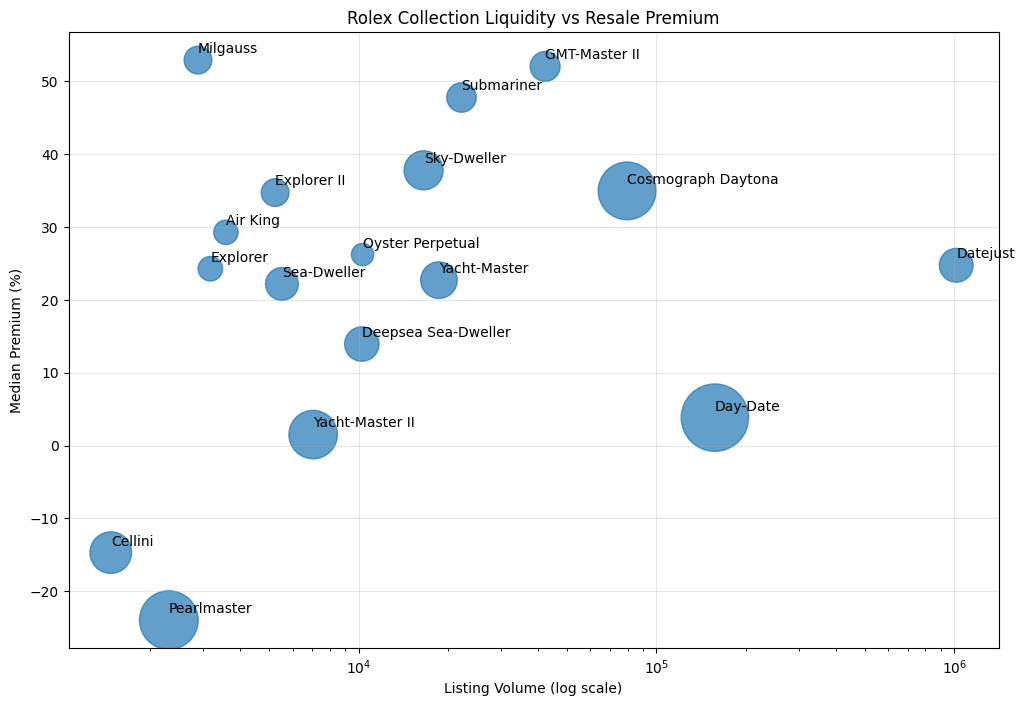

In [38]:
plt.figure(figsize=(12,8))

plt.scatter(
    collection_analysis['listing_count'],
    collection_analysis['median_premium_pct'],
    s=collection_analysis['median_rrp'] / 20,
    alpha=0.7
)

for collection, row in collection_analysis.iterrows():

    plt.text(
        row['listing_count'],
        row['median_premium_pct'] + 1,
        collection,
        fontsize=10
    )

plt.xscale('log')

plt.xlabel('Listing Volume (log scale)')
plt.ylabel('Median Premium (%)')

plt.title('Rolex Collection Liquidity vs Resale Premium')

plt.grid(alpha=0.3)

plt.show()

The Rolex secondary market appears highly segmented across collections.
While models such as GMT-Master II and Submariner combine both high liquidity and strong resale premiums, other collections such as Day-Date exhibit high market presence but relatively limited premium performance.

This suggests that resale value is not solely driven by retail price positioning, but also by collector demand, sports-watch desirability, and scarcity dynamics.

In [39]:
import re
import numpy as np

def extract_year(text):

    match = re.search(r'(19\d{2}|20\d{2})', str(text))

    if match:
        return int(match.group())

    return np.nan

In [40]:
df_merge['production_year'] = (
    df_merge['name']
    .apply(extract_year)
)

In [41]:
df_merge[
    ['name', 'production_year']
].head(20)

,name,production_year
0,"Rolex GMT-Master II ""Rootbeer"" 40MM Two-Tone O...",NaN
1,Rolex GMT-Master II 116710LN 40mm + Box,NaN
2,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
3,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
4,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
5,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
6,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
7,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
8,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN
9,Rolex Datejust 36 116234 Blue Roman Dial with ...,NaN


In [42]:
df_merge['production_year'].notna().mean()

0.30160765660375943

In [43]:
df_year = df_merge[
    df_merge['production_year'].notna()
].copy()

In [44]:
df_year['production_year'].describe()

count    885749.000000
mean       2017.343513
std          14.980553
min        1901.000000
25%        2020.000000
50%        2023.000000
75%        2024.000000
max        2099.000000
Name: production_year, dtype: float64

In [45]:
df_year = df_year[
    (df_year['production_year'] >= 1900) &
    (df_year['production_year'] <= 2025)
]

In [46]:
df_year['production_year'].describe()

count    884619.000000
mean       2017.309578
std          14.937963
min        1901.000000
25%        2020.000000
50%        2023.000000
75%        2024.000000
max        2025.000000
Name: production_year, dtype: float64

In [47]:
df_year['year_bucket'] = (
    (df_year['production_year'] // 5) * 5
)

In [48]:
year_analysis = (
    df_year
    .groupby('year_bucket')
    .agg({
        'premium_pct': 'median',
        'price': 'count',
        'RRP_clean': 'median'
    })
    .rename(columns={
        'price': 'listing_count',
        'RRP_clean': 'median_rrp'
    })
    .reset_index()
)

In [49]:
year_analysis = (
    year_analysis
    .sort_values('year_bucket')
)

year_analysis

,year_bucket,premium_pct,listing_count,median_rrp
0,1900.0,NaN,707,NaN
1,1905.0,NaN,1780,NaN
2,1910.0,NaN,75,NaN
3,1915.0,NaN,90,NaN
4,1920.0,NaN,190,NaN
5,1925.0,NaN,120,NaN
6,1930.0,NaN,217,NaN
7,1935.0,NaN,418,NaN
8,1940.0,NaN,368,NaN
9,1945.0,NaN,560,NaN


The resale premium analysis primarily reflects modern Rolex references for which MSRP data could be reliably matched. Vintage references are underrepresented due to limited availability of historical retail pricing data, which may bias premium estimates toward contemporary market dynamics.

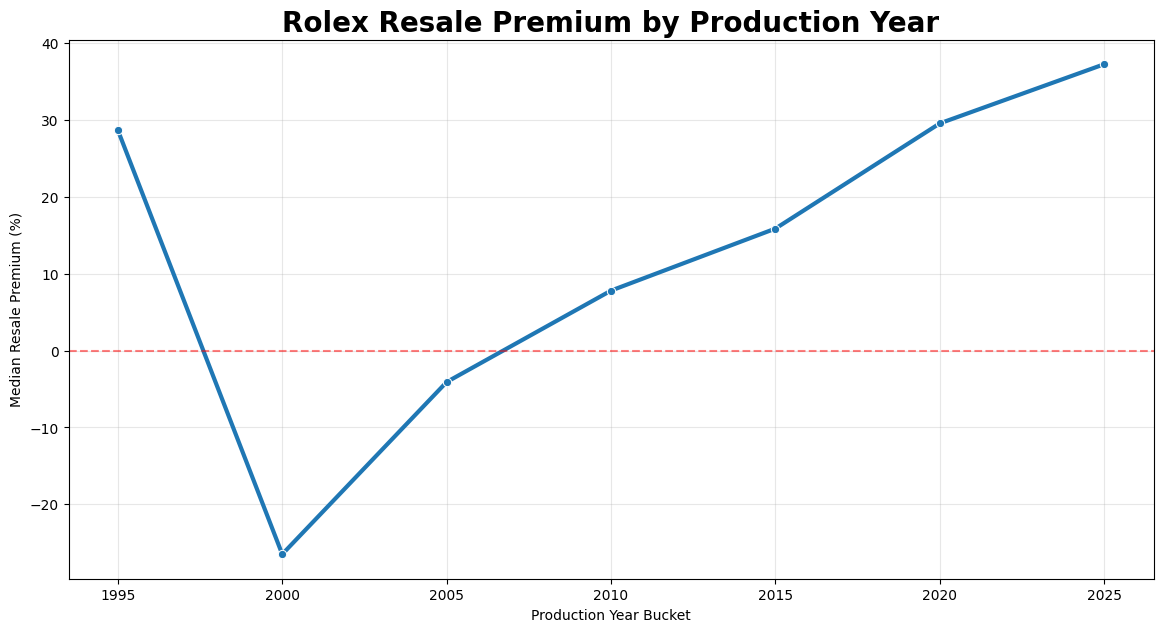

In [50]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=year_analysis,
    x='year_bucket',
    y='premium_pct',
    marker='o',
    linewidth=3
)

plt.axhline(
    0,
    linestyle='--',
    color='red',
    alpha=0.5
)

plt.title(
    'Rolex Resale Premium by Production Year',
    fontsize=20,
    weight='bold'
)

plt.xlabel('Production Year Bucket')
plt.ylabel('Median Resale Premium (%)')

plt.grid(alpha=0.3)

plt.show()

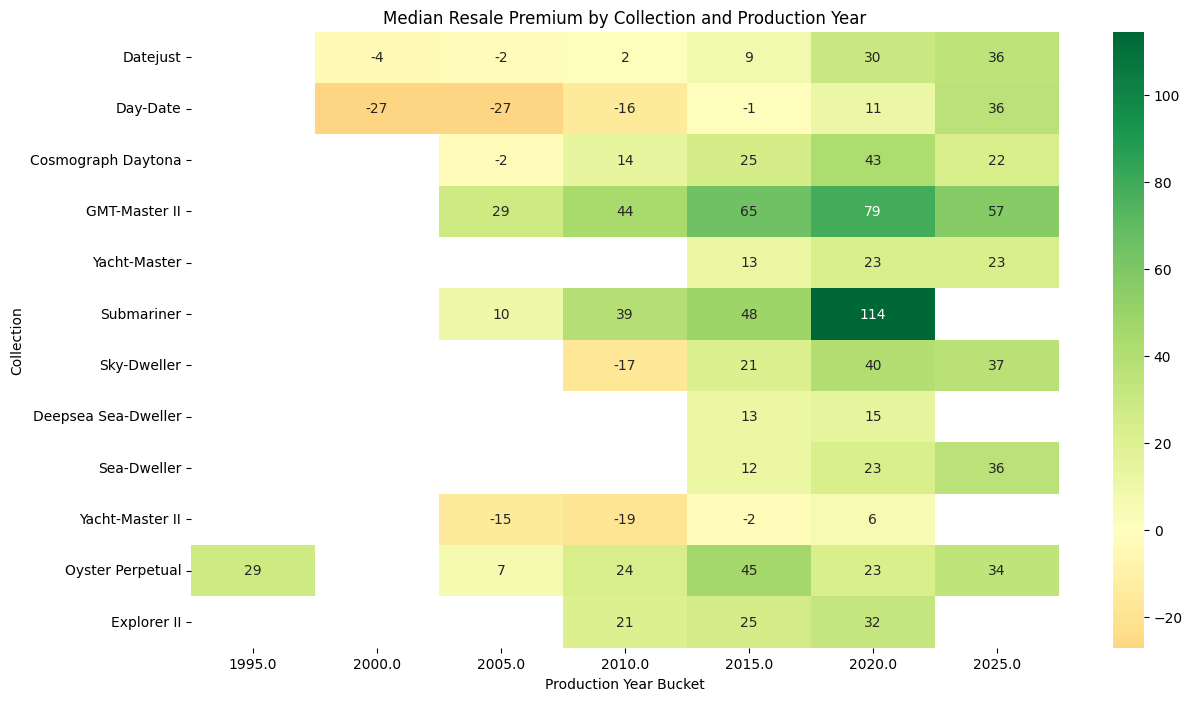

In [51]:
#Collection × Year heatmap

import matplotlib.pyplot as plt
import seaborn as sns

df_heatmap = df_year[
    df_year['premium_pct'].notna()
].copy()

collection_year = (
    df_heatmap
    .groupby(['Collection', 'year_bucket'])['premium_pct']
    .median()
    .unstack()
)

# keep collections with enough data
top_collections = (
    df_heatmap['Collection']
    .value_counts()
    .head(12)
    .index
)

collection_year = collection_year.loc[top_collections]

plt.figure(figsize=(14, 8))

sns.heatmap(
    collection_year,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title('Median Resale Premium by Collection and Production Year')
plt.xlabel('Production Year Bucket')
plt.ylabel('Collection')

plt.show()

In [52]:
#Material × Premium
def extract_material(text):
    text = str(text).lower()

    if 'steel' in text or 'stainless' in text:
        return 'Steel'
    elif 'two-tone' in text or 'two tone' in text:
        return 'Two-tone'
    elif 'rose gold' in text or 'everose' in text:
        return 'Rose Gold'
    elif 'white gold' in text:
        return 'White Gold'
    elif 'yellow gold' in text or 'gold' in text:
        return 'Yellow Gold'
    elif 'platinum' in text:
        return 'Platinum'
    else:
        return 'Unknown'

df_heatmap['material'] = df_heatmap['name'].apply(extract_material)

material_premium = (
    df_heatmap[df_heatmap['material'] != 'Unknown']
    .groupby('material')
    .agg({
        'premium_pct': 'median',
        'price': 'count'
    })
    .rename(columns={
        'premium_pct': 'median_premium_pct',
        'price': 'listing_count'
    })
    .sort_values('median_premium_pct', ascending=False)
)

material_premium

,median_premium_pct,listing_count
material,,
Steel,30.453149,103877
Platinum,26.864536,3438
Yellow Gold,26.256983,27028
Two-tone,22.465438,27594
Rose Gold,18.529092,20391
White Gold,9.655803,19446


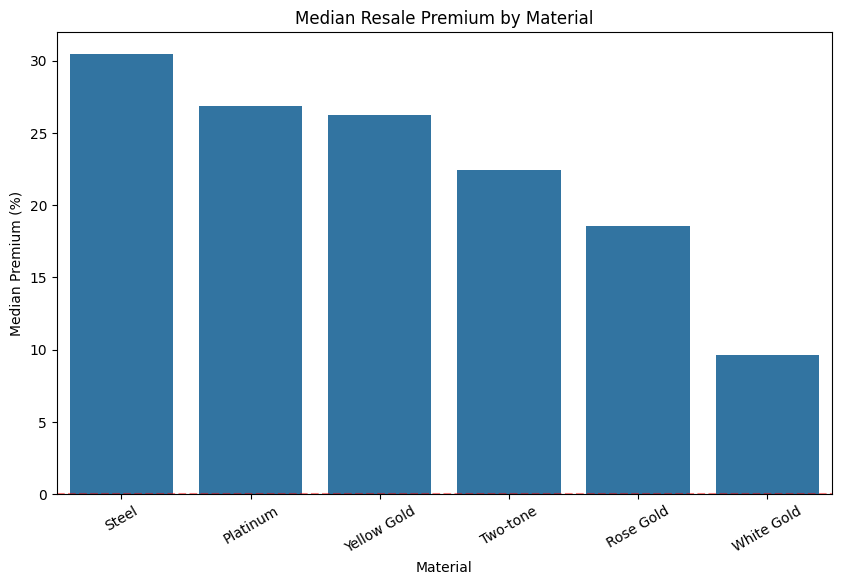

In [53]:
material_premium_plot = material_premium[
    material_premium['listing_count'] > 500
].reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=material_premium_plot,
    x='material',
    y='median_premium_pct'
)

plt.axhline(0, linestyle='--', color='red', alpha=0.5)

plt.title('Median Resale Premium by Material')
plt.xlabel('Material')
plt.ylabel('Median Premium (%)')

plt.xticks(rotation=30)

plt.show()

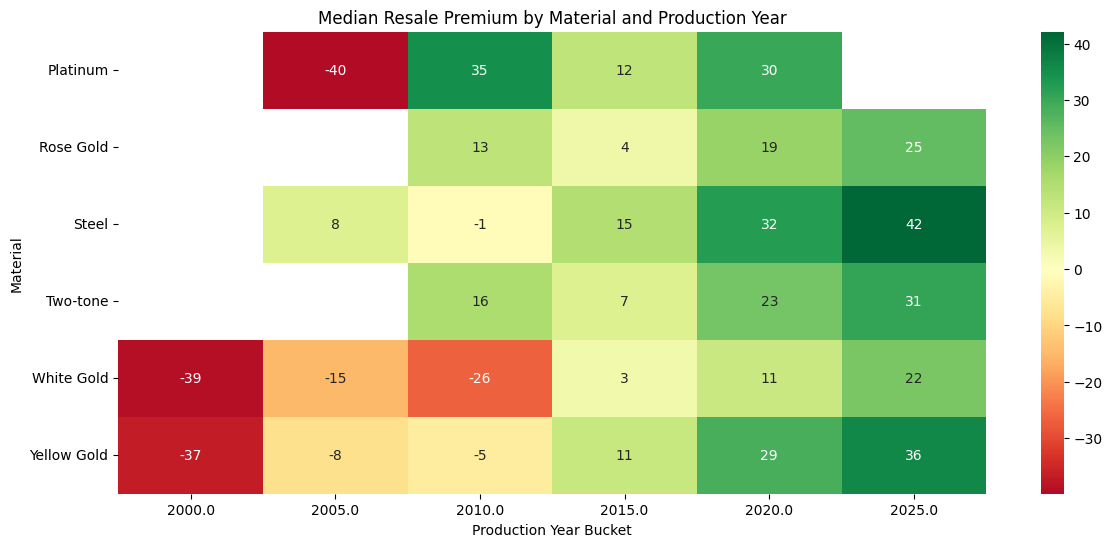

In [54]:
#Material × Year heatmap
material_year = (
    df_heatmap[
        df_heatmap['material'] != 'Unknown'
    ]
    .groupby(['material', 'year_bucket'])['premium_pct']
    .median()
    .unstack()
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    material_year,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title('Median Resale Premium by Material and Production Year')
plt.xlabel('Production Year Bucket')
plt.ylabel('Material')

plt.show()

In [55]:
#Feature Drivers of Premium
def extract_dial_color(text):

    text = str(text).lower()

    if 'green' in text:
        return 'Green'
    elif 'blue' in text:
        return 'Blue'
    elif 'black' in text:
        return 'Black'
    elif 'white' in text:
        return 'White'
    elif 'silver' in text:
        return 'Silver'
    elif 'champagne' in text:
        return 'Champagne'
    elif 'brown' in text:
        return 'Brown'
    else:
        return 'Other'


df_year['dial_color'] = (
    df_year['name']
    .apply(extract_dial_color)
)

In [56]:
sports_models = [
    'Submariner',
    'GMT-Master II',
    'Cosmograph Daytona',
    'Explorer',
    'Explorer II',
    'Sea-Dweller',
    'Deepsea Sea-Dweller',
    'Yacht-Master',
    'Yacht-Master II',
    'Sky-Dweller',
    'Oyster Perpetual'
]

df_year['watch_type'] = (
    df_year['Collection']
    .apply(
        lambda x:
        'Sports'
        if x in sports_models
        else 'Dress'
    )
)

In [57]:
def extract_size(text):

    text = str(text)

    match = re.search(r'(\d{2})mm', text.lower())

    if match:
        return int(match.group(1))

    return None


df_year['size_mm'] = (
    df_year['name']
    .apply(extract_size)
)

In [58]:
def extract_complication(text):

    text = str(text).lower()

    if 'gmt' in text:
        return 'GMT'

    elif 'chronograph' in text or 'daytona' in text:
        return 'Chronograph'

    elif 'sky-dweller' in text:
        return 'Annual Calendar'

    elif 'datejust' in text or 'day-date' in text:
        return 'Date'

    else:
        return 'Simple Time'


df_year['complication_type'] = (
    df_year['name']
    .apply(extract_complication)
)

In [59]:
dial_analysis = (
    df_year
    .groupby('dial_color')
    .agg({
        'premium_pct': 'median',
        'price': 'count'
    })
    .rename(columns={
        'premium_pct': 'median_premium_pct',
        'price': 'listing_count'
    })
    .sort_values(
        'median_premium_pct',
        ascending=False
    )
)

dial_analysis

,median_premium_pct,listing_count
dial_color,,
Green,39.136126,61761
Blue,29.363002,95601
Other,27.994012,431990
Silver,27.986306,53223
Black,26.164773,105578
Champagne,23.456790,35472
White,20.056543,82655
Brown,13.387978,3825


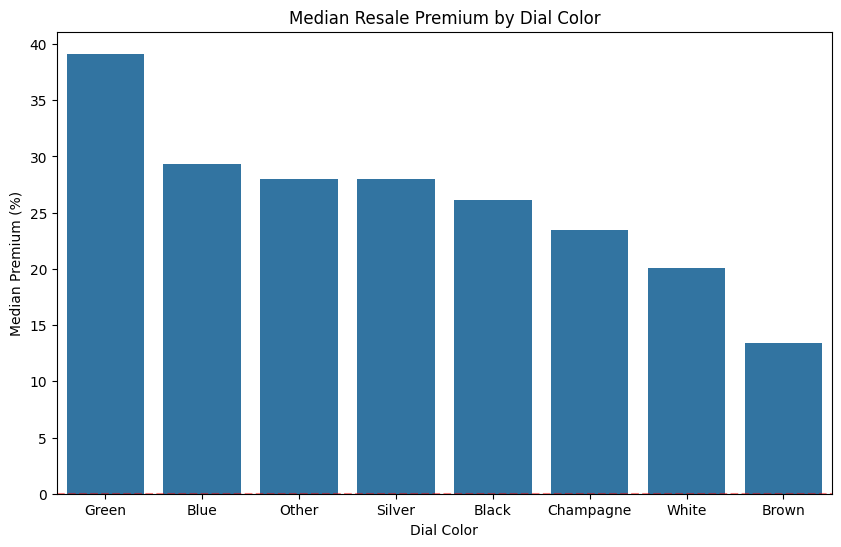

In [60]:
dial_plot = (
    dial_analysis[
        dial_analysis['listing_count'] > 3000
    ]
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=dial_plot,
    x='dial_color',
    y='median_premium_pct'
)

plt.axhline(
    0,
    linestyle='--',
    color='red',
    alpha=0.5
)

plt.title(
    'Median Resale Premium by Dial Color'
)

plt.xlabel('Dial Color')
plt.ylabel('Median Premium (%)')

plt.show()

In [61]:
type_analysis = (
    df_year
    .groupby('watch_type')
    ['premium_pct']
    .median()
)

type_analysis

watch_type
Dress     26.016260
Sports    36.332448
Name: premium_pct, dtype: float64

In [62]:
complication_analysis = (
    df_year
    .groupby('complication_type')
    .agg({
        'premium_pct':'median',
        'price':'count'
    })
    .sort_values(
        'premium_pct',
        ascending=False
    )
)

complication_analysis

,premium_pct,price
complication_type,,
GMT,64.042793,54789
Chronograph,38.230266,61184
Annual Calendar,35.732323,23795
Date,25.987973,550405
Simple Time,24.958848,179932


In [63]:
size_analysis = (
    df_year[
        df_year['size_mm'].between(34, 44)
    ]
    .groupby('size_mm')
    ['premium_pct']
    .median()
)

size_analysis

size_mm
34.0     0.528288
35.0          NaN
36.0    19.292929
37.0    17.073280
38.0          NaN
39.0    28.092949
40.0    28.205128
41.0    25.526316
42.0    26.222283
43.0    20.986842
44.0     4.754738
Name: premium_pct, dtype: float64

In [64]:
# 1. Create material column in df_year

def extract_material(text):
    text = str(text).lower()

    if 'steel' in text or 'stainless' in text:
        return 'Steel'
    elif 'two-tone' in text or 'two tone' in text:
        return 'Two-tone'
    elif 'rose gold' in text or 'everose' in text:
        return 'Rose Gold'
    elif 'white gold' in text:
        return 'White Gold'
    elif 'yellow gold' in text:
        return 'Yellow Gold'
    elif 'platinum' in text:
        return 'Platinum'
    elif 'gold' in text:
        return 'Yellow Gold'
    else:
        return 'Unknown'

df_year['material'] = df_year['name'].apply(extract_material)

In [65]:
# 2. Create complication_type column in df_year

def extract_complication(text):
    text = str(text).lower()

    if 'gmt' in text:
        return 'GMT'
    elif 'daytona' in text or 'chronograph' in text:
        return 'Chronograph'
    elif 'sky-dweller' in text:
        return 'Annual Calendar'
    elif 'submariner' in text or 'sea-dweller' in text or 'deepsea' in text:
        return 'Diver'
    elif 'datejust' in text or 'day-date' in text:
        return 'Date'
    else:
        return 'Simple Time'

df_year['complication_type'] = df_year['name'].apply(extract_complication)

In [66]:
df_year[['name', 'material', 'complication_type']].head(20)

,name,material,complication_type
13,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,White Gold,Date
14,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,White Gold,Date
15,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,White Gold,Date
16,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,White Gold,Date
19,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,Rose Gold,Date
20,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,Rose Gold,Date
21,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,Rose Gold,Date
32,Rolex Submariner Date 16610 40mm 2024 Rolex Se...,Unknown,Diver
44,Rolex NEW 2024 Datejust 36 AUBERGINE DIAL FACT...,Unknown,Date
45,Rolex NEW 2024 Datejust 36 AUBERGINE DIAL FACT...,Unknown,Date


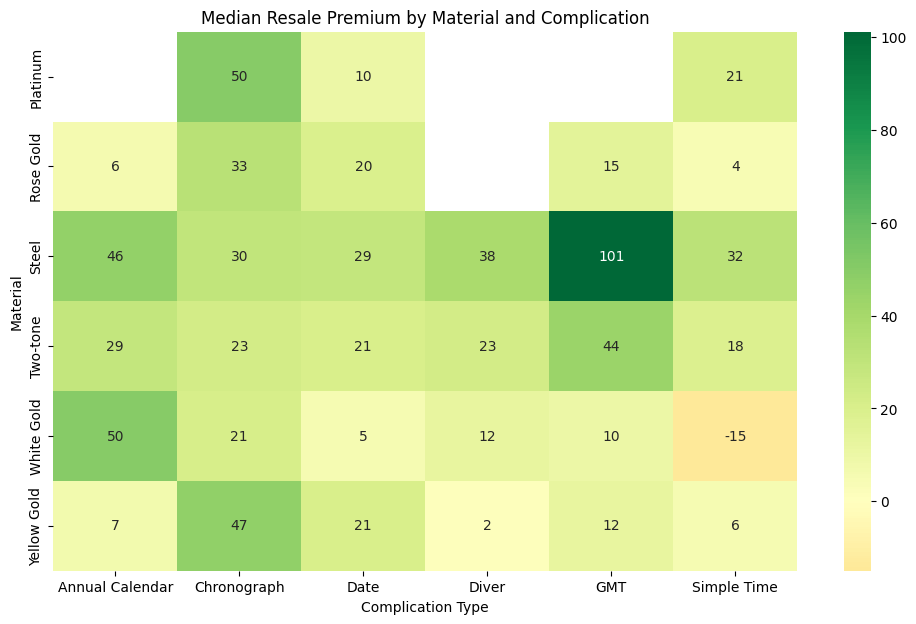

In [67]:
feature_heatmap = (
    df_year[
        (df_year['material'] != 'Unknown') &
        (df_year['premium_pct'].notna())
    ]
    .groupby(['material', 'complication_type'])['premium_pct']
    .median()
    .unstack()
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    feature_heatmap,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title('Median Resale Premium by Material and Complication')
plt.xlabel('Complication Type')
plt.ylabel('Material')

plt.show()

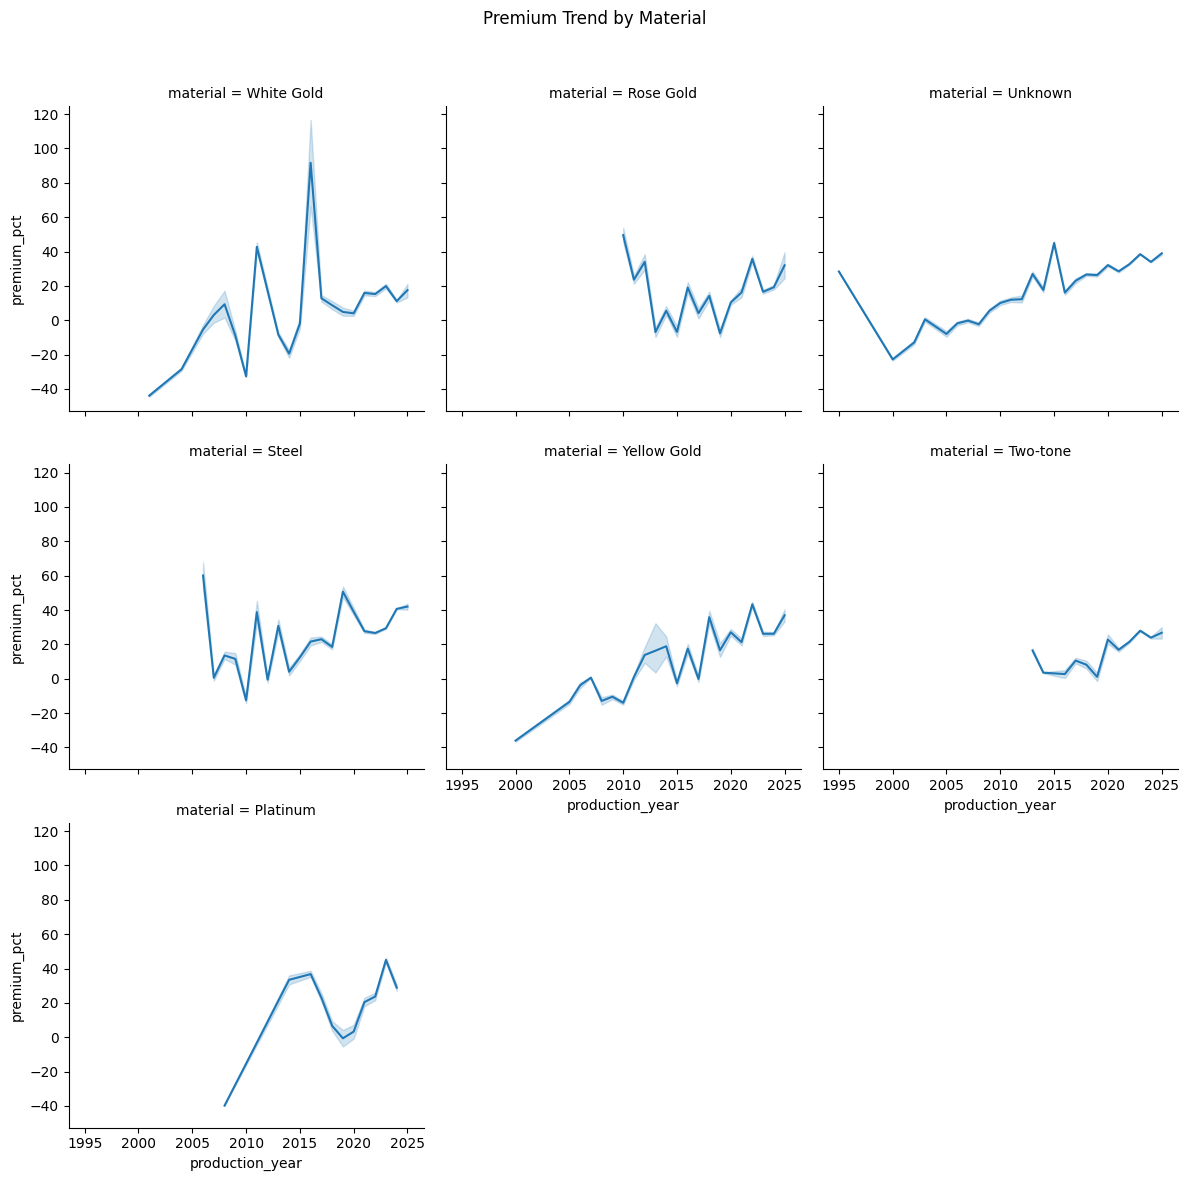

In [68]:
g = sns.FacetGrid(
    df_year,
    col='material',
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.lineplot,
    x='production_year',
    y='premium_pct'
)

g.fig.subplots_adjust(top=0.9)

g.fig.suptitle(
    'Premium Trend by Material'
)

plt.show()

In [69]:
# 1. Build premium + volume table

feature_matrix = (
    df_year[
        (df_year['material'] != 'Unknown') &
        (df_year['premium_pct'].notna())
    ]
    .groupby(['material', 'complication_type'])
    .agg(
        median_premium_pct=('premium_pct', 'median'),
        listing_count=('price', 'count')
    )
    .reset_index()
)

feature_matrix

,material,complication_type,median_premium_pct,listing_count
0,Platinum,Chronograph,50.304414,1340
1,Platinum,Date,9.630267,1601
2,Platinum,Simple Time,20.811518,497
3,Rose Gold,Annual Calendar,6.096724,594
4,Rose Gold,Chronograph,32.856730,3194
5,Rose Gold,Date,19.704050,12227
6,Rose Gold,GMT,14.651985,1803
7,Rose Gold,Simple Time,4.166667,2573
8,Steel,Annual Calendar,46.021021,949
9,Steel,Chronograph,29.807692,2002


In [70]:
# 2. Keep only combinations with enough listings

feature_matrix_filtered = feature_matrix[
    feature_matrix['listing_count'] > 1000
].copy()

feature_matrix_filtered

,material,complication_type,median_premium_pct,listing_count
0,Platinum,Chronograph,50.304414,1340
1,Platinum,Date,9.630267,1601
4,Rose Gold,Chronograph,32.856730,3194
5,Rose Gold,Date,19.704050,12227
6,Rose Gold,GMT,14.651985,1803
7,Rose Gold,Simple Time,4.166667,2573
9,Steel,Chronograph,29.807692,2002
10,Steel,Date,29.094412,91868
11,Steel,Diver,38.216846,2353
12,Steel,GMT,101.182796,2651


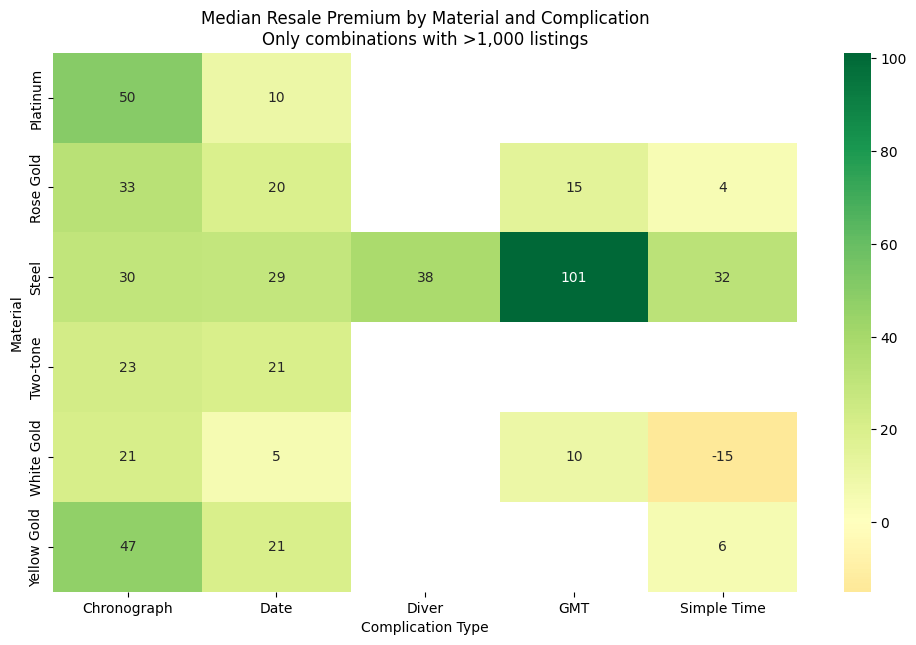

In [71]:
# 3. Create heatmap table

premium_heatmap = feature_matrix_filtered.pivot(
    index='material',
    columns='complication_type',
    values='median_premium_pct'
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    premium_heatmap,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title('Median Resale Premium by Material and Complication\nOnly combinations with >1,000 listings')
plt.xlabel('Complication Type')
plt.ylabel('Material')

plt.show()

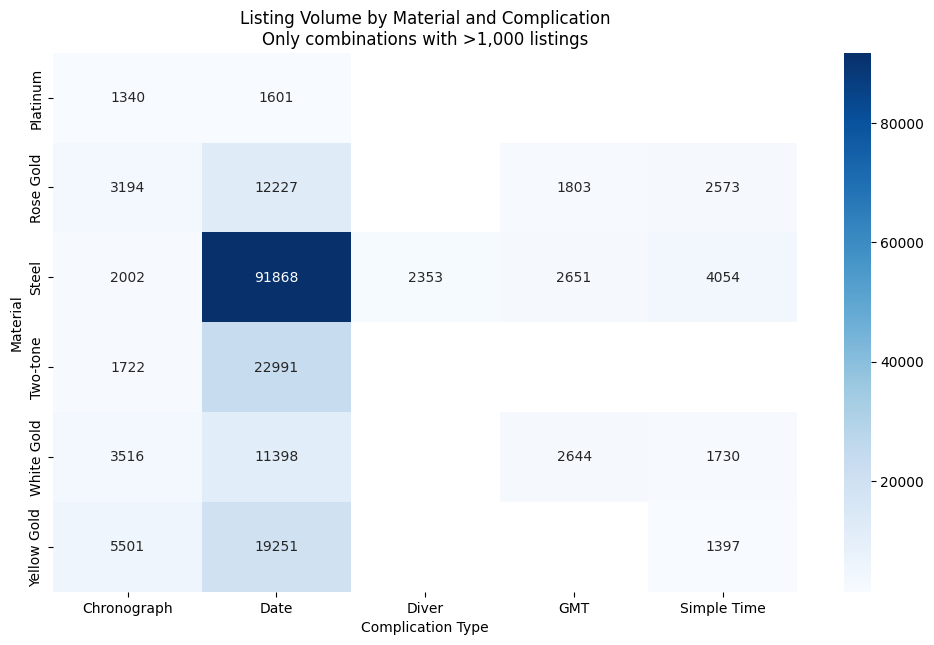

In [72]:
volume_heatmap = feature_matrix_filtered.pivot(
    index='material',
    columns='complication_type',
    values='listing_count'
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    volume_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title('Listing Volume by Material and Complication\nOnly combinations with >1,000 listings')
plt.xlabel('Complication Type')
plt.ylabel('Material')

plt.show()

In [73]:
def extract_size(text):

    text = str(text).lower()

    # first try : 40mm / 40 mm
    match = re.search(r'(\d{2})\s*mm', text)

    if match:
        return int(match.group(1))

    # second try : standalone 2-digit sizes
    match = re.search(r'\b(28|31|34|36|37|39|40|41|42|43|44)\b', text)

    if match:
        return int(match.group(1))

    return None


In [74]:
df_year['size_mm'] = df_year['name'].apply(extract_size)

In [75]:
df_year[['name', 'size_mm']].head(20)

,name,size_mm
13,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,40.0
14,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,40.0
15,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,40.0
16,Rolex NEW 2024 BLUE OMBRÉ Day-Date 40 BLUE OMB...,40.0
19,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,40.0
20,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,40.0
21,Rolex UNPOLISHED 2016 Like NEW Day-Date 40 Pre...,40.0
32,Rolex Submariner Date 16610 40mm 2024 Rolex Se...,40.0
44,Rolex NEW 2024 Datejust 36 AUBERGINE DIAL FACT...,36.0
45,Rolex NEW 2024 Datejust 36 AUBERGINE DIAL FACT...,36.0


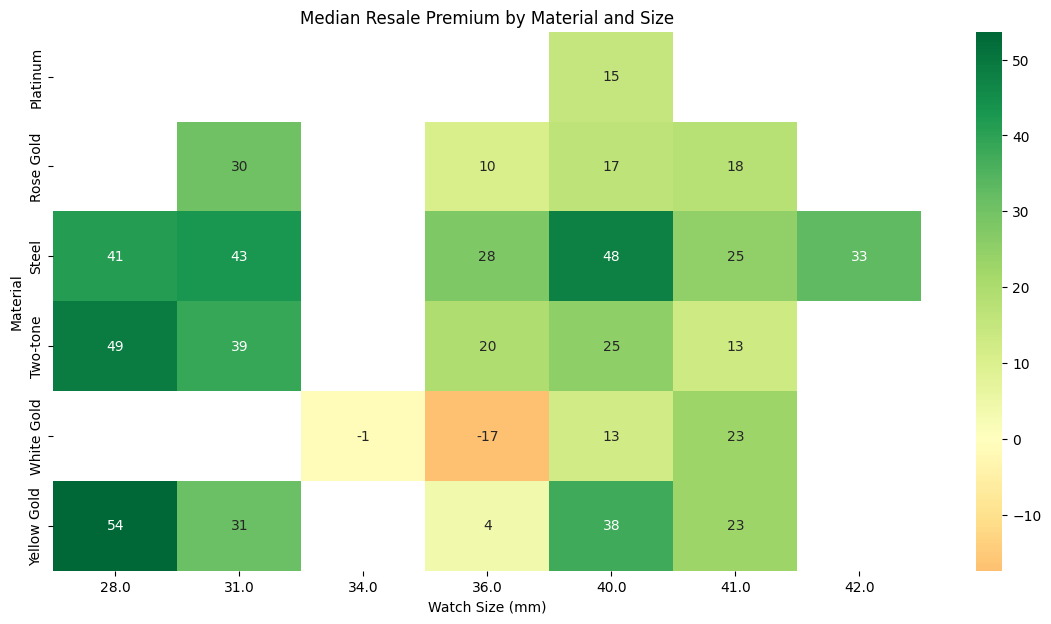

In [76]:
size_material = (
    df_year[
        (df_year['size_mm'].notna()) &
        (df_year['material'] != 'Unknown') &
        (df_year['premium_pct'].notna())
    ]
    .groupby(['material', 'size_mm'])
    .agg(
        median_premium_pct=('premium_pct', 'median'),
        listing_count=('price', 'count')
    )
    .reset_index()
)

size_material = size_material[
    size_material['listing_count'] > 500
]

size_material_heatmap = size_material.pivot(
    index='material',
    columns='size_mm',
    values='median_premium_pct'
)

plt.figure(figsize=(14,7))

sns.heatmap(
    size_material_heatmap,
    annot=True,
    fmt=".0f",
    cmap='RdYlGn',
    center=0
)

plt.title('Median Resale Premium by Material and Size')
plt.xlabel('Watch Size (mm)')
plt.ylabel('Material')

plt.show()

In [77]:
trend_complication = (
    df_year[
        (df_year['complication_type'] != 'Unknown') &
        (df_year['premium_pct'].notna())
    ]
    .groupby(
        ['year_bucket', 'complication_type']
    )
    .agg(
        median_premium_pct=('premium_pct', 'median'),
        listing_count=('price', 'count')
    )
    .reset_index()
)

trend_complication = trend_complication[
    trend_complication['listing_count'] > 1000
]

In [78]:
trend_heatmap = trend_complication.pivot(
    index='complication_type',
    columns='year_bucket',
    values='median_premium_pct'
)

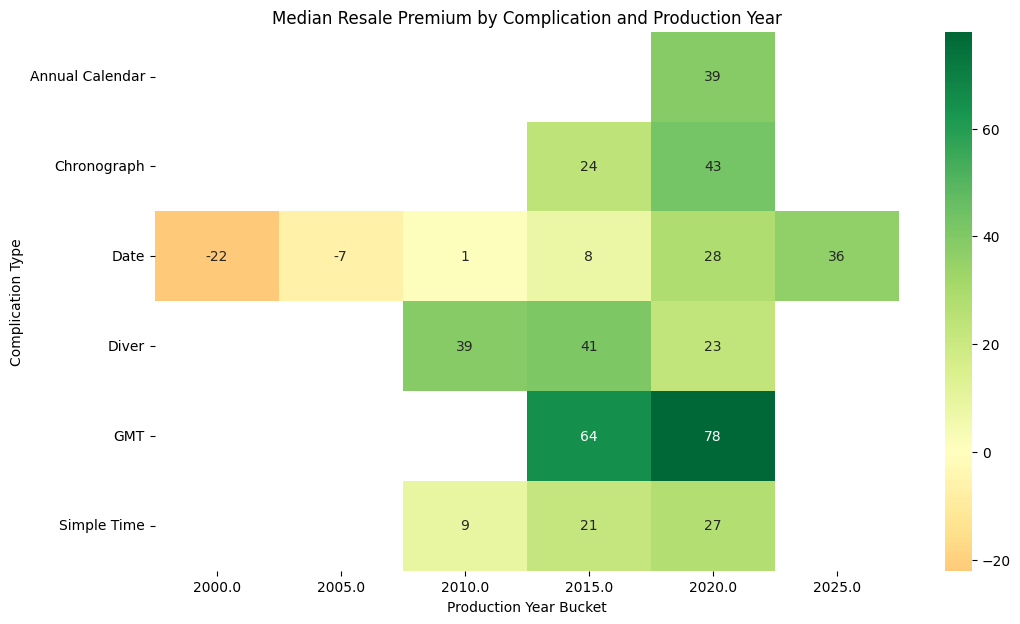

In [79]:
plt.figure(figsize=(12,7))

sns.heatmap(
    trend_heatmap,
    annot=True,
    fmt=".0f",
    cmap='RdYlGn',
    center=0
)

plt.title('Median Resale Premium by Complication and Production Year')
plt.xlabel('Production Year Bucket')
plt.ylabel('Complication Type')

plt.show()

# Rolex Historical Market Analysis

This section investigates the long-term market dynamics
of Rolex references within the luxury watch secondary market.

The objective is to understand how liquidity, collection type,
and reference concentration contribute to resale premium formation.

In [80]:
#Sports vs Classic
sports_vs_classic = (
    df_year
    .dropna(subset=["premium_pct"])
    .groupby("watch_type")
    .agg(
        listing_count=("price", "count"),
        median_premium_pct=("premium_pct", "median"),
        mean_premium_pct=("premium_pct", "mean")
    )
    .reset_index()
)

sports_vs_classic


,watch_type,listing_count,median_premium_pct,mean_premium_pct
0,Dress,447956,26.016260,26.720144
1,Sports,83275,36.332448,51.844525


While both segments generate positive resale premiums,
sports-oriented Rolex references display substantially stronger
premium intensity and greater upside dispersion.

The gap between median and mean premium within the sports segment
suggests the presence of highly speculative outlier references,
particularly within GMT-Master II and Daytona families.

In [81]:
#reference-level concentration
reference_analysis = (
    df_year
    .dropna(subset=["premium_pct"])
    .groupby("reference")
    .agg(
        listing_count=("price", "count"),
        median_premium_pct=("premium_pct", "median"),
        mean_premium_pct=("premium_pct", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
)

reference_analysis = (
    reference_analysis[
        reference_analysis["listing_count"] > 500
    ]
    .sort_values(
        "median_premium_pct",
        ascending=False
    )
)

reference_analysis.head(20)


,reference,listing_count,median_premium_pct,mean_premium_pct,median_price
69,126710BLRO,4205,136.612903,139.767916,22005.0
24,116610LV,2200,127.660044,149.848876,20626.0
10,116500LN,2997,124.452381,128.548244,28281.0
68,126710BLNR,4414,89.000000,91.271224,17577.0
130,279174,1498,78.027778,80.400282,12200.0
36,116710BLNR,1080,72.353604,75.807088,15305.0
123,279160,568,59.793814,46.558808,9390.0
113,278273,14392,59.511785,58.914304,18450.0
14,116508,4257,58.710285,77.612679,58225.0
138,326934,3082,58.265766,61.852206,21081.0


Resale premium concentration appears highly reference-specific.

A limited number of sports-oriented Rolex references,
particularly GMT-Master II and Daytona models,
capture disproportionately large premiums despite already high liquidity.

This suggests that collector attention and scarcity dynamics
are concentrated around a narrow speculative segment
within the broader Rolex ecosystem.

In [87]:
# Friendly labels for key references

reference_labels = {
    "126710BLRO": "GMT Pepsi",
    "116610LV": "Submariner Hulk",
    "116500LN": "Daytona Panda",
    "126710BLNR": "GMT Batman",
    "116710BLNR": "GMT Batman (older)",
    "116710LN": "GMT Black",
    "116508": "Daytona Green Dial",
    "326934": "Sky-Dweller Blue",
    "279174": "Lady-Datejust",
    "279160": "Lady-Datejust",
    "278273": "Lady-Datejust Two-tone"
}

# Sports / hype references

sports_hype_refs = [
    "126710BLRO",
    "116610LV",
    "116500LN",
    "126710BLNR",
    "116710BLNR",
    "116710LN",
    "116508",
    "326934"
]

# Create segment

reference_analysis["segment"] = np.where(
    reference_analysis["reference"].isin(sports_hype_refs),
    "Sports / hype references",
    "Classic / mainstream references"
)


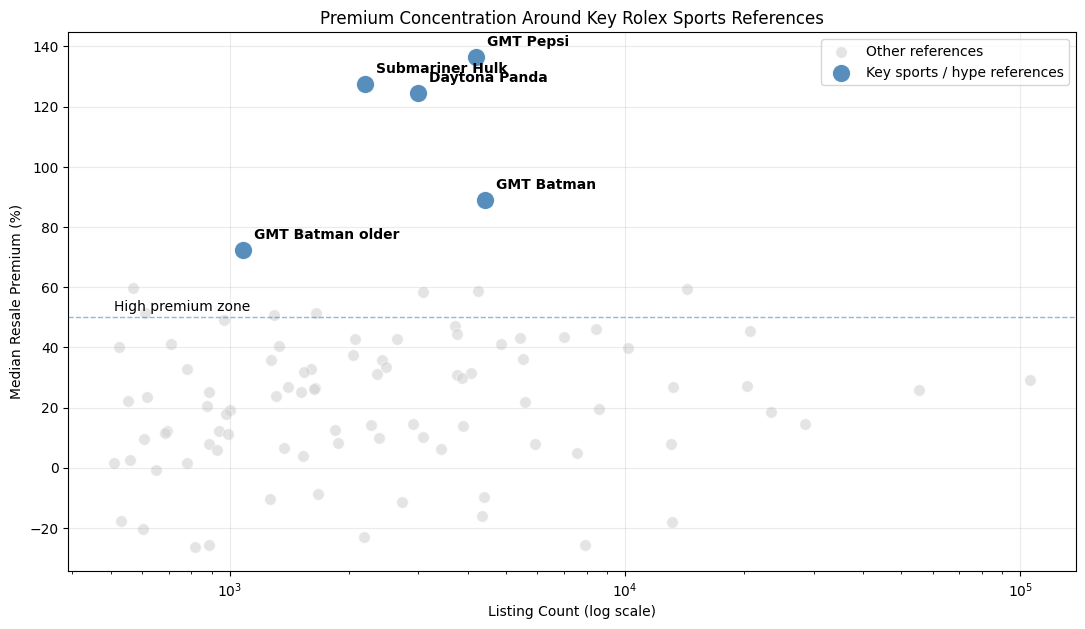

In [89]:
# Cleaner reference liquidity vs premium chart

highlight_refs = {
    "126710BLRO": "GMT Pepsi",
    "116610LV": "Submariner Hulk",
    "116500LN": "Daytona Panda",
    "126710BLNR": "GMT Batman",
    "116710BLNR": "GMT Batman older",
}

reference_analysis["is_highlight"] = reference_analysis["reference"].isin(
    highlight_refs.keys()
)

plt.figure(figsize=(13, 7))

# Background points
sns.scatterplot(
    data=reference_analysis[~reference_analysis["is_highlight"]],
    x="listing_count",
    y="median_premium_pct",
    color="lightgrey",
    s=70,
    alpha=0.6,
    label="Other references"
)

# Highlight points
sns.scatterplot(
    data=reference_analysis[reference_analysis["is_highlight"]],
    x="listing_count",
    y="median_premium_pct",
    color="steelblue",
    s=180,
    alpha=0.9,
    label="Key sports / hype references"
)

# Labels only for key references
for _, row in reference_analysis[reference_analysis["is_highlight"]].iterrows():
    plt.annotate(
        highlight_refs[row["reference"]],
        xy=(row["listing_count"], row["median_premium_pct"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        weight="bold"
    )

plt.xscale("log")

plt.axhline(
    50,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

plt.text(
    reference_analysis["listing_count"].min(),
    52,
    "High premium zone",
    fontsize=10
)

plt.xlabel("Listing Count (log scale)")
plt.ylabel("Median Resale Premium (%)")
plt.title("Premium Concentration Around Key Rolex Sports References")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

The Rolex secondary market does not exhibit a simple linear relationship
between liquidity and resale premium.

Instead, premium concentration appears clustered around a limited number
of highly liquid sports-oriented references, particularly within the
GMT-Master II and Daytona families.

References such as GMT Pepsi, Daytona Panda, and Submariner Hulk display
both strong market liquidity and exceptionally high resale premiums,
suggesting speculative collector dynamics beyond traditional luxury pricing.

In contrast, mainstream collections such as Datejust maintain high market
presence but generate more moderate premium intensity, indicating that
liquidity alone does not fully explain resale performance.

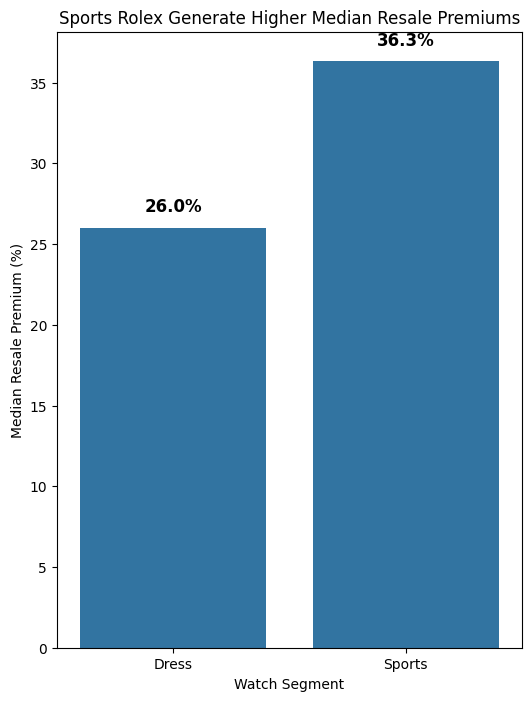

In [95]:
segment_summary = (
    df_year
    .dropna(subset=["premium_pct"])
    .groupby("watch_type")
    .agg(
        listing_count=("price", "count"),
        median_premium_pct=("premium_pct", "median"),
        mean_premium_pct=("premium_pct", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(6,8))

sns.barplot(
    data=segment_summary,
    x="watch_type",
    y="median_premium_pct"
)

plt.title("Sports Rolex Generate Higher Median Resale Premiums")
plt.xlabel("Watch Segment")
plt.ylabel("Median Resale Premium (%)")

for i, row in segment_summary.iterrows():
    plt.text(
        i,
        row["median_premium_pct"] + 1,
        f'{row["median_premium_pct"]:.1f}%',
        ha="center",
        fontsize=12,
        weight="bold"
    )

plt.show()

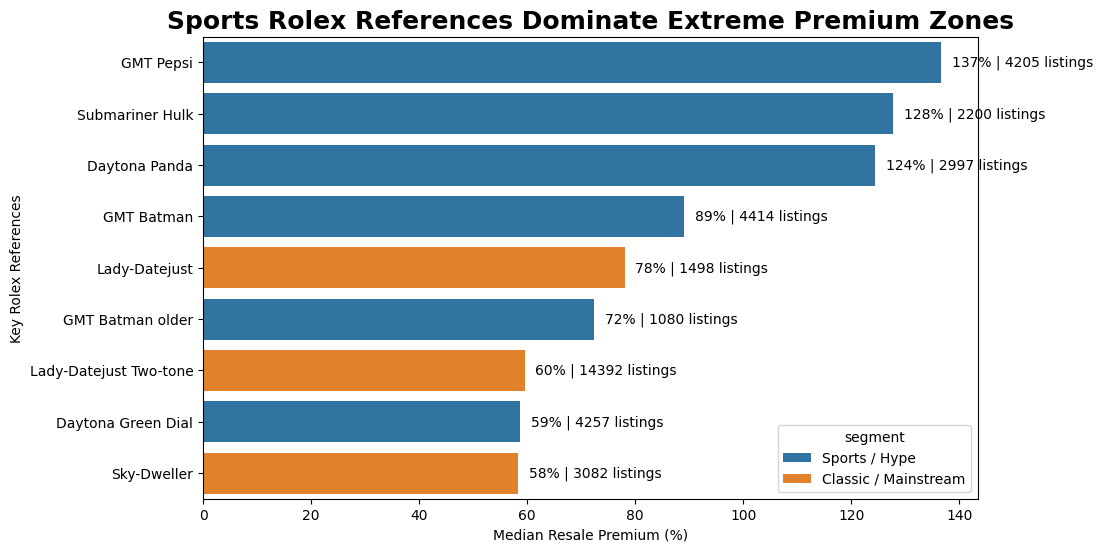

In [98]:
top_refs_plot = top_refs_plot[
    top_refs_plot["reference_label"] != top_refs_plot["reference"]
]

reference_labels = {
    "126710BLRO": "GMT Pepsi",
    "116610LV": "Submariner Hulk",
    "116500LN": "Daytona Panda",
    "126710BLNR": "GMT Batman",
    "116710BLNR": "GMT Batman older",
    "116710LN": "GMT Black",
    "116508": "Daytona Green Dial",
    "326934": "Sky-Dweller",
    "279174": "Lady-Datejust",
    "278273": "Lady-Datejust Two-tone"
}

top_refs_plot["segment"] = np.where(
    top_refs_plot["reference_label"].isin([
        "GMT Pepsi",
        "GMT Batman",
        "GMT Batman older",
        "Daytona Panda",
        "Submariner Hulk",
        "Daytona Green Dial"
    ]),
    "Sports / Hype",
    "Classic / Mainstream"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_refs_plot,
    y="reference_label",
    x="median_premium_pct",
    hue="segment"
)

plt.title(
    "Sports Rolex References Dominate Extreme Premium Zones",
    fontsize=18,
    weight="bold"
)
plt.xlabel("Median Resale Premium (%)")
plt.ylabel("Key Rolex References")

for i, row in top_refs_plot.reset_index(drop=True).iterrows():
    plt.text(
        row["median_premium_pct"] + 2,
        i,
        f'{row["median_premium_pct"]:.0f}% | {int(row["listing_count"])} listings',
        va="center",
        fontsize=10
    )

plt.show()

Sports-oriented Rolex references dominate the highest premium tier
within the secondary market.

GMT-Master II, Submariner, and Daytona references consistently
generate substantially higher resale premiums than mainstream
or dress-oriented models.

This concentration dynamic suggests that resale value formation
is increasingly driven by collector desirability, scarcity,
and market attention rather than retail positioning alone.